In [ ]:
#cargo mis bases
import pandas as pd
df= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_base_pivot_var_rpta_alt_enmascarado_trtest.csv')
df3= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_probabilidad_oblig_base_hist_enmascarado_completa.csv')
df2= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_master_customer_data_enmascarado_completa.csv')
df4= pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_maestra_cuotas_pagos_mes_hist_enmascarado_completa.csv')
predecir = pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_base_pivot_var_rpta_alt_enmascarado_oot.csv')

c:\Users\daniealv\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (28,37,38) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\daniealv\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (5,6) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\daniealv\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (17,18,19,30,31) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [218]:
predecir = df[['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'fecha_var_rpta_alt','var_rpta_alt']]

In [ ]:
#cuento os valores para ver si existe desbalance
conteo_var_rpta = final1['var_rpta_alt'].value_counts()
print(conteo_var_rpta)

0    295483
1    272768
Name: var_rpta_alt, dtype: int64


In [ ]:
#conviero mi columna en fecha para luego realizar filtros y cruces
predecir['fecha_var_rpta_alt'] = pd.to_datetime(predecir['fecha_var_rpta_alt'], format='%Y%m')

C:\Users\daniealv\AppData\Local\Temp/ipykernel_3580/2672788435.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predecir['fecha_var_rpta_alt'] = pd.to_datetime(predecir['fecha_var_rpta_alt'], format='%Y%m')


In [ ]:
merged_df = pd.merge(predecir, df4, how='left', on=['nit_enmascarado', 'num_oblig_enmascarado'])
# Convertir las columnas 'fecha_corte' y 'fecha_var_rpta_alt' en tipo datetime
merged_df['fecha_corte'] = pd.to_datetime(merged_df['fecha_corte'], format='%Y%m%d')
merged_df['fecha_var_rpta_alt'] = pd.to_datetime(merged_df['fecha_var_rpta_alt'], format='%Y%m')
merged_df['fecha_corte'] = merged_df['fecha_corte'].apply(lambda x: x.replace(day=1))
merged_df = merged_df[merged_df['fecha_var_rpta_alt'] > merged_df['fecha_corte']]
merged_df = merged_df.drop(columns=['fecha_pago_minima', 'fecha_pago_maxima'])

# Agrupar por las columnas especificadas y contar las ocurrencias de cada valor en 'marca_pago'
marca_pago_counts = merged_df.groupby(['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt', 'marca_pago']).size().unstack(fill_value=0).reset_index()
# Renombrar las columnas para que sean más descriptivas
marca_pago_counts.columns = ['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt'] + [f'count_{col}' for col in marca_pago_counts.columns[4:]]


merged_df = merged_df.sort_values(by=['nit_enmascarado', 'fecha_corte'])



In [ ]:
# Me quedo con mi registro mas actual, esto se puede optimizar mediante un join con la comparción de fechas
merged_df = merged_df.drop_duplicates(subset=['nit_enmascarado','num_oblig_enmascarado','num_oblig_orig_enmascarado','fecha_var_rpta_alt'], keep='last')


In [223]:
merged_df = merged_df[['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt', 'producto', 'aplicativo', 'segmento', 'valor_cuota_mes', 'pago_total', 'porc_pago','marca_pago']]

In [224]:
# Calcular nuevamente porc_pago si es nulo
merged_df['porc_pago'] = merged_df.apply(
    lambda row: (row['pago_total'] / row['valor_cuota_mes']) * 100 if pd.isnull(row['porc_pago']) and row['valor_cuota_mes'] != 0 else (0 if row['valor_cuota_mes'] == 0 and row['pago_total'] == 0 else row['porc_pago']),
    axis=1
)

In [ ]:
#creo una nueva variable para los pagos de mi cliente
merged_df['marca_pago2'] = merged_df.apply(
    lambda row: 'paga mas' if row['pago_total'] > row['valor_cuota_mes'] else (
        'paga menos' if row['pago_total'] < row['valor_cuota_mes'] else (
            'pago completo' if row['pago_total'] == row['valor_cuota_mes'] else ''
        )
    ) if row['pago_total'] == 0 and row['valor_cuota_mes'] == 0 else 'cancelado',
    axis=1
)

In [62]:
merged_df2=merged_df.copy()

In [ ]:

merged_result = pd.merge(merged_df2, predecir, on=['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado'], how='left')
print(merged_result)

# Mostrar la relación de las variables categóricas con 'var_rpta_alt' de manera de conteo
# Crear variables con cada salida
conteo_producto = merged_result.groupby('producto')['var_rpta_alt'].value_counts().unstack(fill_value=0)
conteo_aplicativo = merged_result.groupby('aplicativo')['var_rpta_alt'].value_counts().unstack(fill_value=0)
conteo_segmento = merged_result.groupby('segmento')['var_rpta_alt'].value_counts().unstack(fill_value=0)
conteo_marca_pago2 = merged_result.groupby('marca_pago2')['var_rpta_alt'].value_counts().unstack(fill_value=0)




        nit_enmascarado  num_oblig_enmascarado  num_oblig_orig_enmascarado  \
0                    12                 457040                      623302   
1                    24                 996548                       91197   
2                    29                 617042                      463300   
3                    39                 263144                      817198   
4                    55                 267129                      813213   
...                 ...                    ...                         ...   
143095           634681                 744868                      335716   
143096           634681                 894270                      193982   
143097           634685                1051333                       53619   
143098           634695                 914235                      173880   
143099           634695                 633420                      446928   

                  producto aplicativo       segmento  valor_cuo

In [ ]:
#convierto mis variables en numericas
df3['prob_alrt_temprana'] = pd.to_numeric(df3['prob_alrt_temprana'], errors='coerce')
df3['prob_auto_cura'] = pd.to_numeric(df3['prob_auto_cura'], errors='coerce')
merged_df = pd.merge(predecir, df3, how='left', on=['nit_enmascarado', 'num_oblig_enmascarado'])
# Convertir las columnas 'fecha_corte' y 'fecha_var_rpta_alt' en tipo datetime
merged_df['fecha_corte'] = pd.to_datetime(merged_df['fecha_corte'], format='%Y%m')
merged_df['fecha_var_rpta_alt'] = pd.to_datetime(merged_df['fecha_var_rpta_alt'], format='%Y%m')
merged_df = merged_df[merged_df['fecha_var_rpta_alt'] > merged_df['fecha_corte']]

In [64]:
# Ordenar el DataFrame por 'nit_enmascarado', 'num_oblig_enmascarado' y 'fecha_corte'
merged_df = merged_df.sort_values(by=['nit_enmascarado', 'num_oblig_enmascarado', 'fecha_corte'])

# Eliminar duplicados, manteniendo solo el último registro de 'fecha_corte'
merged_df = merged_df.drop_duplicates(subset=['nit_enmascarado', 'num_oblig_enmascarado'], keep='last')

In [65]:
merged_df2 = merged_df2.drop(columns=['marca_pago'])

In [ ]:

final_merged_df = pd.merge(predecir, merged_df2, on=['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado','fecha_var_rpta_alt'], how='left')

In [ ]:

final_merged_df = pd.merge(final_merged_df, merged_df, on=['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado','fecha_var_rpta_alt'], how='left')

In [70]:
final_merged_df = final_merged_df.drop(columns=['var_rpta_alt_x', 'var_rpta_alt_y'])

In [71]:
final_merged_df = pd.merge(final_merged_df, marca_pago_counts, on=['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado','fecha_var_rpta_alt'], how='left')

In [72]:
count_columns = [col for col in final_merged_df.columns if col.startswith('count_')]
final_merged_df[count_columns] = final_merged_df[count_columns].fillna(0)

In [73]:
final_merged_df = final_merged_df.drop(columns=['lote'])

In [74]:
final=final_merged_df.copy()

In [ ]:
final_merged_df=final.copy()

In [75]:
final_merged_df = final_merged_df.drop(columns=['fecha_corte'])

In [76]:
# Reemplazar valores infinitos en la columna 'porc_pago' con '1'
final_merged_df['porc_pago'] = final_merged_df['porc_pago'].replace([float('inf'), float('-inf')], 1)

In [77]:
from sklearn.impute import SimpleImputer

# Imputar variables categóricas con la moda
categorical_columns = final_merged_df.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
final_merged_df[categorical_columns] = categorical_imputer.fit_transform(final_merged_df[categorical_columns])

# Imputar variables numéricas con la media
numerical_columns = final_merged_df.select_dtypes(include=['float64', 'int64']).columns
numerical_imputer = SimpleImputer(strategy='mean')
final_merged_df[numerical_columns] = numerical_imputer.fit_transform(final_merged_df[numerical_columns])

In [78]:
# Crear variables dummies para las columnas categóricas en final_merged_df
final_merged_df = pd.get_dummies(final_merged_df, columns=['producto', 'aplicativo', 'segmento', 'marca_pago2'], drop_first=True)


In [ ]:
# from sklearn.impute import KNNImputer

# # Define the columns to exclude from imputation
# exclude_columns = ['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'fecha_var_rpta_alt']

# # Select the columns to impute
# columns_to_impute = final_merged_df.columns.difference(exclude_columns)

# # Initialize the KNNImputer
# imputer = KNNImputer()



In [ ]:

final_merged_df = pd.merge(final_merged_df, predecir, on=['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'fecha_var_rpta_alt'], how='left')

In [80]:
final1=final_merged_df.copy()

In [113]:
final_merged_df=final1.copy()

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Definir las columnas identificadoras y la variable objetivo
id_columns = ['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt']
target_column = 'var_rpta_alt'

# Separar las características y la variable objetivo
X = final_merged_df.drop(columns=id_columns + [target_column])
y = final_merged_df[target_column]


In [ ]:
# from sklearn.preprocessing import StandardScaler

# # Inicializar el escalador
# scaler = StandardScaler()

# # Ajustar y transformar los datos
# X = scaler.fit_transform(X)

In [115]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
    
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)



c:\Users\daniealv\Anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [116]:
print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'ROC AUC Score: {roc_auc}')

Accuracy: 0.6718198696007954
F1 Score: 0.639256422160322
ROC AUC Score: 0.7355542082925552


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb

# Definir los modelos a evaluar
models = {
    'RandomForest': ,
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(),
    'DecisionTree': DecisionTreeClassifier(),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}
RandomForestClassifier()
# Diccionario para almacenar los resultados
results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("termino modelo " + name)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

# Mostrar los resultados
for name, metrics in results.items():
    print(f"Model: {name}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print()

# Seleccionar el mejor modelo basado en ROC AUC
best_model_name = max(results, key=lambda name: results[name]['ROC AUC'])
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

In [ ]:
from sklearn.model_selection import GridSearchCV
# Definir el modelo
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Definir los hiperparámetros a buscar
param_grid = {
    'n_estimators': [100, 200,300],
    'max_depth': [3, 5,9],
    'learning_rate': [0.01, 0.2],
    'subsample': [0.8, 1.0]
}

# Configurar GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=2, scoring='roc_auc', verbose=2, n_jobs=-1)

# Ejecutar GridSearchCV
grid_search.fit(X_train, y_train)

# Obtener los mejores hiperparámetros
best_params = grid_search.best_params_
print("Mejores hiperparámetros:", best_params)

# Entrenar el modelo con los mejores hiperparámetros
best_xgb_model = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
best_xgb_model.fit(X_train, y_train)

# Evaluar el modelo
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

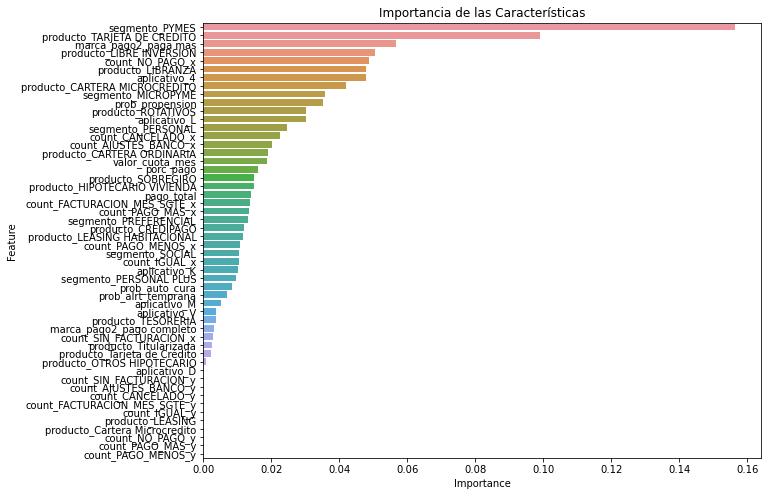

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Obtener las importancias de las características
importances = best_xgb_model.feature_importances_

# Crear un DataFrame para facilitar la visualización
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Ordenar las características por importancia
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Visualizar las importancias de las características
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Importancia de las Características')
plt.show()

<module 'matplotlib.pyplot' from 'c:\\Users\\daniealv\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

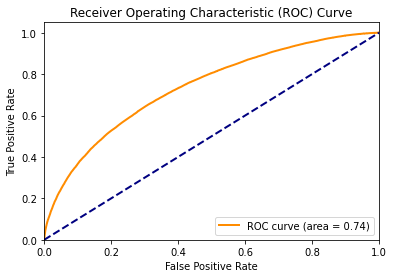

In [214]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Pintar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt

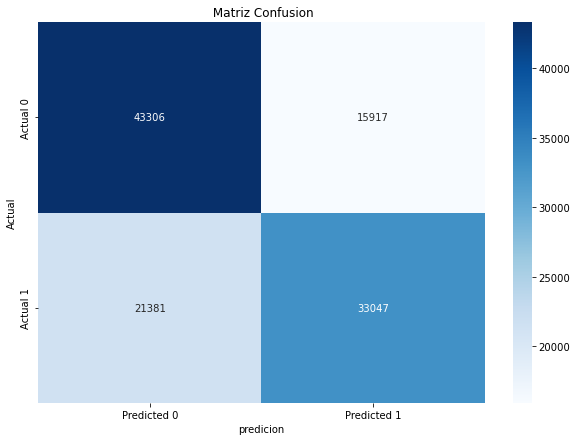

In [216]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear un heatmap para la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('predicion')
plt.ylabel('Actual')
plt.title(' Matriz Confusion')
plt.show()

In [146]:

predecir = pd.read_csv(r'C:\Users\daniealv\Downloads\prueba_op_base_pivot_var_rpta_alt_enmascarado_oot.csv')
predecir['fecha_var_rpta_alt'] = pd.to_datetime(predecir['fecha_var_rpta_alt'], format='%Y%m')

In [ ]:
merged_df = pd.merge(predecir, df4, how='left', on=['nit_enmascarado', 'num_oblig_enmascarado'])
merged_df['fecha_corte'] = pd.to_datetime(merged_df['fecha_corte'], format='%Y%m%d')
merged_df['fecha_var_rpta_alt'] = pd.to_datetime(merged_df['fecha_var_rpta_alt'], format='%Y%m')
merged_df['fecha_corte'] = merged_df['fecha_corte'].apply(lambda x: x.replace(day=1))
merged_df = merged_df[merged_df['fecha_var_rpta_alt'] > merged_df['fecha_corte']]
merged_df = merged_df.drop(columns=['fecha_pago_minima', 'fecha_pago_maxima'])
marca_pago_counts = merged_df.groupby(['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt', 'marca_pago']).size().unstack(fill_value=0).reset_index()
marca_pago_counts.columns = ['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt'] + [f'count_{col}' for col in marca_pago_counts.columns[4:]]
merged_df = merged_df.sort_values(by=['nit_enmascarado', 'fecha_corte'])
merged_df = merged_df.drop_duplicates(subset=['nit_enmascarado','num_oblig_enmascarado','num_oblig_orig_enmascarado','fecha_var_rpta_alt'], keep='last')



In [148]:
marca_pago_counts = marca_pago_counts.drop(columns=['fecha_var_rpta_alt'])

In [149]:
merged_df = merged_df[['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado', 'fecha_var_rpta_alt', 'producto', 'aplicativo', 'segmento', 'valor_cuota_mes', 'pago_total', 'porc_pago','marca_pago']]

In [ ]:

merged_df['porc_pago'] = merged_df.apply(
    lambda row: (row['pago_total'] / row['valor_cuota_mes']) * 100 if pd.isnull(row['porc_pago']) and row['valor_cuota_mes'] != 0 else (0 if row['valor_cuota_mes'] == 0 and row['pago_total'] == 0 else row['porc_pago']),
    axis=1
)

In [151]:
merged_df['marca_pago2'] = merged_df.apply(
    lambda row: 'paga mas' if row['pago_total'] > row['valor_cuota_mes'] else (
        'paga menos' if row['pago_total'] < row['valor_cuota_mes'] else (
            'pago completo' if row['pago_total'] == row['valor_cuota_mes'] else ''
        )
    ) if row['pago_total'] == 0 and row['valor_cuota_mes'] == 0 else 'cancelado',
    axis=1
)

In [152]:
merged_df2=merged_df.copy()

In [ ]:
df3['prob_alrt_temprana'] = pd.to_numeric(df3['prob_alrt_temprana'], errors='coerce')
df3['prob_auto_cura'] = pd.to_numeric(df3['prob_auto_cura'], errors='coerce')
merged_df = pd.merge(predecir, df3, how='left', on=['nit_enmascarado', 'num_oblig_enmascarado'])
merged_df['fecha_corte'] = pd.to_datetime(merged_df['fecha_corte'], format='%Y%m')
merged_df['fecha_var_rpta_alt'] = pd.to_datetime(merged_df['fecha_var_rpta_alt'], format='%Y%m')
merged_df = merged_df[merged_df['fecha_var_rpta_alt'] > merged_df['fecha_corte']]

In [ ]:

merged_df = merged_df.sort_values(by=['nit_enmascarado', 'num_oblig_enmascarado', 'fecha_corte'])

merged_df = merged_df.drop_duplicates(subset=['nit_enmascarado', 'num_oblig_enmascarado'], keep='last')

In [155]:
merged_df2 = merged_df2.drop(columns=['fecha_var_rpta_alt','marca_pago'])

In [ ]:

final_merged_df = pd.merge(predecir, merged_df2, on=['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado'], how='left')

In [157]:
merged_df = merged_df.drop(columns=['fecha_var_rpta_alt'])

In [ ]:

final_merged_df = pd.merge(final_merged_df, merged_df, on=['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado'], how='left')

In [159]:
final_merged_df = pd.merge(final_merged_df, marca_pago_counts, on=['nit_enmascarado', 'num_oblig_enmascarado', 'num_oblig_orig_enmascarado'], how='left')

In [160]:
final_merged_df = final_merged_df.drop(columns=['lote'])

In [161]:
final=final_merged_df.copy()

In [ ]:
final_merged_df=final.copy()

In [162]:
final_merged_df = final_merged_df.drop(columns=['fecha_corte'])

In [163]:
count_columns = [col for col in final_merged_df.columns if col.startswith('count_')]
final_merged_df[count_columns] = final_merged_df[count_columns].fillna(0)

In [ ]:

final_merged_df['porc_pago'] = final_merged_df['porc_pago'].replace([float('inf'), float('-inf')], 1)

In [ ]:


categorical_columns = final_merged_df.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
final_merged_df[categorical_columns] = categorical_imputer.fit_transform(final_merged_df[categorical_columns])

numerical_columns = final_merged_df.select_dtypes(include=['float64', 'int64']).columns
numerical_imputer = SimpleImputer(strategy='mean')
final_merged_df[numerical_columns] = numerical_imputer.fit_transform(final_merged_df[numerical_columns])

In [ ]:

final_merged_df = pd.get_dummies(final_merged_df, columns=['producto', 'aplicativo', 'segmento', 'marca_pago2'], drop_first=True)


In [ ]:
# Gobtener columasn es final1 y no estan en final_merged_df
columns_in_final1_not_in_final_merged_df = set(final1.columns) - set(final_merged_df.columns)
print(columns_in_final1_not_in_final_merged_df)

{'count_NO_PAGO_x', 'count_CANCELADO_x', 'count_PAGO_MENOS_y', 'count_FACTURACION_MES_SGTE_y', 'count_PAGO_MAS_y', 'count_SIN_FACTURACION_x', 'count_IGUAL_x', 'producto_CARTERA MICROCREDITO', 'producto_Cartera Microcredito', 'count_AJUSTES_BANCO_x', 'var_rpta_alt', 'count_FACTURACION_MES_SGTE_x', 'count_AJUSTES_BANCO_y', 'count_NO_PAGO_y', 'producto_Tarjeta de Crédito', 'count_CANCELADO_y', 'count_IGUAL_y', 'count_SIN_FACTURACION_y', 'count_PAGO_MAS_x', 'count_PAGO_MENOS_x'}


In [ ]:
# Obtener las columnas que están en final1 pero no en final_merged_df, excluyendo var_rpta_alt
columns_to_add = set(final1.columns) - set(final_merged_df.columns) - {'var_rpta_alt'}

# Crear las columnas faltantes en final_merged_df y llenarlas con ceros
for column in columns_to_add:
    final_merged_df[column] = 0


In [168]:
# Obtener las columnas que están en final_merged_df pero no en final1
columns_to_drop = set(final_merged_df.columns) - set(final1.columns)

# Eliminar las columnas de final_merged_df
final_merged_df = final_merged_df.drop(columns=columns_to_drop)

In [174]:
final_merged_df_encoded = final_merged_df.copy()

In [ ]:

# Alinear las columnas de merged_check2_encoded con las de X_train
final_merged_df = final_merged_df.reindex(columns=X_train.columns, fill_value=0)
# Hacer predicciones
predictions = best_xgb_model.predict(final_merged_df)


In [209]:
# Crear un nuevo DataFrame con las columnas requeridas
df_result = final_merged_df_encoded[['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'var_rpta_alt']].copy()

# Convertir las columnas especificadas a int
df_result[['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'var_rpta_alt']] = df_result[['nit_enmascarado', 'num_oblig_orig_enmascarado', 'num_oblig_enmascarado', 'var_rpta_alt']].astype(int)

# Concatenar las columnas con el separador '#'
df_result['ID'] = df_result['nit_enmascarado'].astype(str) + '#' + df_result['num_oblig_orig_enmascarado'].astype(str)+ '#' +df_result['num_oblig_enmascarado'].astype(str) 

# Seleccionar solo las columnas 'ID' y 'var_rpta_alt'
df_result = df_result[['ID', 'var_rpta_alt']]

In [205]:
final_merged_df_encoded['var_rpta_alt'] = predictions

In [ ]:
# Predecir las probabilidades
predictions_proba = best_xgb_model.predict_proba(final_merged_df)[:, 1]

# Agregar las probabilidades al DataFrame
final_merged_df['prob_var_rpta_alt'] = predictions_proba

In [211]:
# Agregar las predicciones al dataframe
final_merged_df['var_rpta_alt'] = predictions

In [212]:
# Asegúrate de que las probabilidades de predicción estén alineadas con el DataFrame df_result
df_result['prob_var_rpta_alt'] = predictions_proba


In [213]:

df_result.to_csv('resultado_prueba.csv', index=False)